# Diagrammi per il documento OmniRetail AI Governance

Genera i sette PNG referenziati dal markdown principale. Eseguire dall'alto in basso. Ogni cella produce un file `0N_*.png` nella stessa directory.

Palette unificata, dimensioni coerenti (12-14 pollici di larghezza), tipografia leggibile per export in Google Docs.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

PALETTE = {
    'primary':   '#2563eb',
    'secondary': '#16a34a',
    'accent':    '#f97316',
    'danger':    '#dc2626',
    'warning':   '#eab308',
    'neutral':   '#6b7280',
    'light':     '#f3f4f6',
    'dark':      '#1f2937',
    'pale_blue': '#dbeafe',
    'pale_green':'#dcfce7',
    'pale_amber':'#fef3c7',
    'pale_red':  '#fee2e2',
    'pale_gray': '#e5e7eb',
}

DPI = 160

## Figura 1 - Matrice di prioritizzazione dei casi d'uso

Quadranti Value × Feasibility, quattro casi d'uso posizionati. I due selezionati per il pilota sono evidenziati.

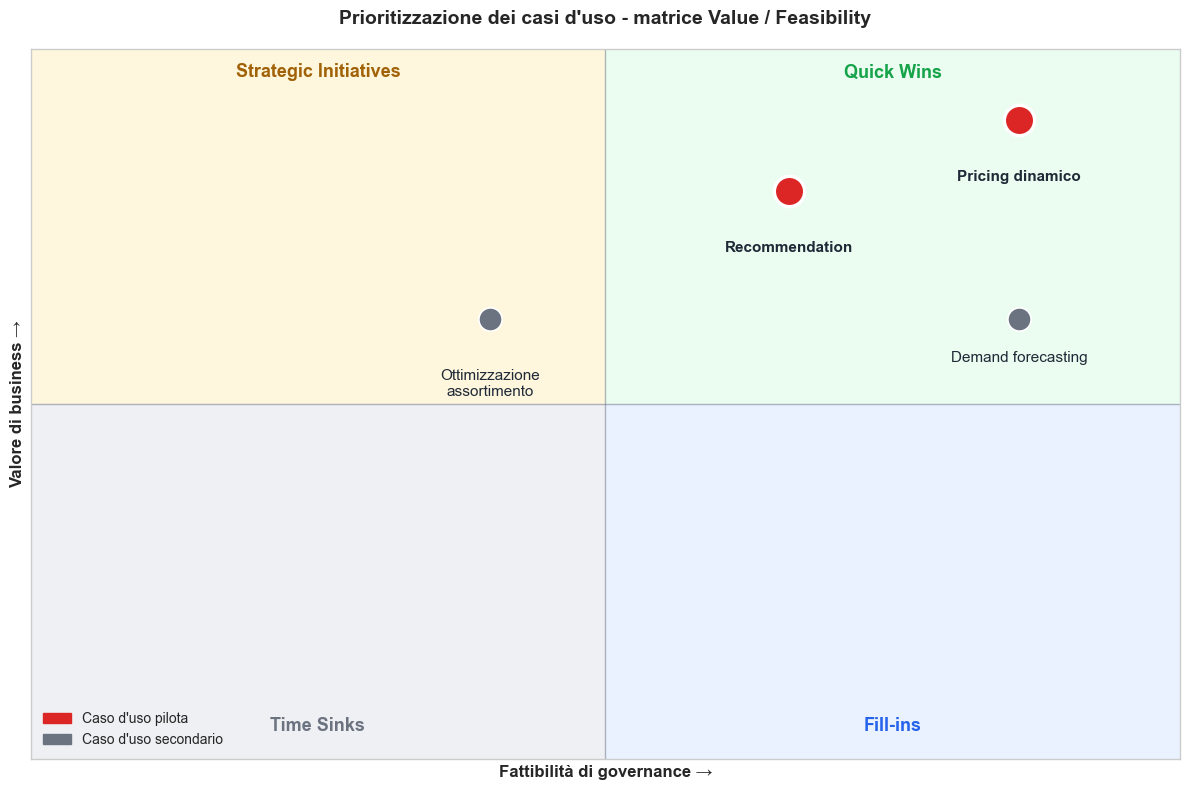

In [2]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.add_patch(Rectangle((0.5, 0.5), 0.5, 0.5, facecolor=PALETTE['pale_green'], alpha=0.6, zorder=0))
ax.add_patch(Rectangle((0.0, 0.5), 0.5, 0.5, facecolor=PALETTE['pale_amber'], alpha=0.6, zorder=0))
ax.add_patch(Rectangle((0.5, 0.0), 0.5, 0.5, facecolor=PALETTE['pale_blue'], alpha=0.6, zorder=0))
ax.add_patch(Rectangle((0.0, 0.0), 0.5, 0.5, facecolor=PALETTE['pale_gray'], alpha=0.6, zorder=0))

ax.text(0.75, 0.96, 'Quick Wins', fontsize=13, fontweight='bold',
        ha='center', color=PALETTE['secondary'])
ax.text(0.25, 0.96, 'Strategic Initiatives', fontsize=13, fontweight='bold',
        ha='center', color='#a16207')
ax.text(0.75, 0.04, 'Fill-ins', fontsize=13, fontweight='bold',
        ha='center', color=PALETTE['primary'])
ax.text(0.25, 0.04, 'Time Sinks', fontsize=13, fontweight='bold',
        ha='center', color=PALETTE['neutral'])

use_cases = [
    {'name': 'Pricing dinamico',   'value': 0.90, 'feas': 0.86, 'pilot': True},
    {'name': 'Recommendation',     'value': 0.80, 'feas': 0.66, 'pilot': True},
    {'name': 'Demand forecasting', 'value': 0.62, 'feas': 0.86, 'pilot': False},
    {'name': 'Ottimizzazione\nassortimento', 'value': 0.62, 'feas': 0.40, 'pilot': False},
]

for uc in use_cases:
    color = PALETTE['danger'] if uc['pilot'] else PALETTE['neutral']
    size = 480 if uc['pilot'] else 280
    edge = 2.5 if uc['pilot'] else 1.2
    ax.scatter(uc['feas'], uc['value'], s=size,
               color=color, edgecolor='white', linewidth=edge, zorder=3)
    label_fontweight = 'bold' if uc['pilot'] else 'normal'
    n_lines = uc['name'].count('\n') + 1
    dy = 0.07 if uc['pilot'] else (0.045 + 0.025 * (n_lines - 1))
    ax.annotate(uc['name'],
                xy=(uc['feas'], uc['value']),
                xytext=(uc['feas'], uc['value'] - dy),
                ha='center', va='top', fontsize=11, fontweight=label_fontweight,
                color=PALETTE['dark'])

ax.axhline(0.5, color=PALETTE['neutral'], linewidth=1, alpha=0.5)
ax.axvline(0.5, color=PALETTE['neutral'], linewidth=1, alpha=0.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Fattibilità di governance →', fontsize=12, fontweight='bold')
ax.set_ylabel('Valore di business →', fontsize=12, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])

pilot_patch = mpatches.Patch(color=PALETTE['danger'], label='Caso d\'uso pilota')
other_patch = mpatches.Patch(color=PALETTE['neutral'], label='Caso d\'uso secondario')
ax.legend(handles=[pilot_patch, other_patch], loc='lower left', fontsize=10,
          framealpha=0.95, edgecolor=PALETTE['neutral'])

ax.set_title('Prioritizzazione dei casi d\'uso - matrice Value / Feasibility',
             fontsize=14, fontweight='bold', pad=18)

plt.tight_layout()
plt.savefig('01_use_case_prioritization.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Figura 2 - Architettura logica

Otto domini funzionali organizzati per layer: presentazione, orchestrazione, core, integrazione.

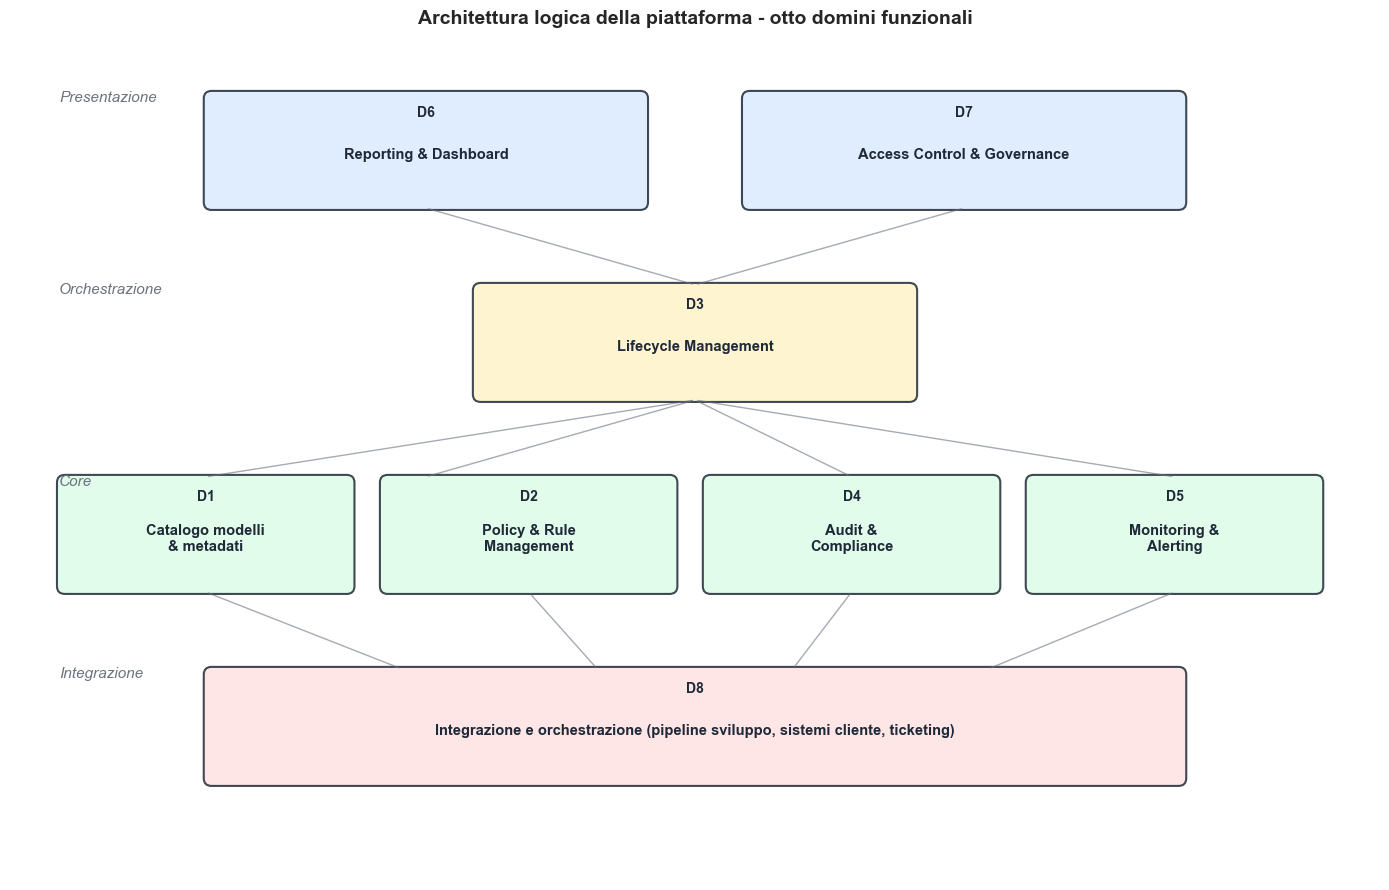

In [3]:
fig, ax = plt.subplots(figsize=(14, 9))

def draw_domain(x, y, w, h, num, name, color, alpha=0.85):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.08',
                         facecolor=color, edgecolor=PALETTE['dark'],
                         linewidth=1.5, alpha=alpha)
    ax.add_patch(box)
    ax.text(x + w/2, y + h - 0.25, f'D{num}', fontsize=10, fontweight='bold',
            ha='center', color=PALETTE['dark'])
    ax.text(x + w/2, y + h/2 - 0.05, name, fontsize=10.5, fontweight='bold',
            ha='center', va='center', color=PALETTE['dark'])

ax.text(0.5, 8.6, 'Presentazione', fontsize=11, color=PALETTE['neutral'], style='italic')
draw_domain(2.0, 7.5, 4.5, 1.2, 6, 'Reporting & Dashboard', PALETTE['pale_blue'])
draw_domain(7.5, 7.5, 4.5, 1.2, 7, 'Access Control & Governance', PALETTE['pale_blue'])

ax.text(0.5, 6.6, 'Orchestrazione', fontsize=11, color=PALETTE['neutral'], style='italic')
draw_domain(4.75, 5.5, 4.5, 1.2, 3, 'Lifecycle Management', PALETTE['pale_amber'])

ax.text(0.5, 4.6, 'Core', fontsize=11, color=PALETTE['neutral'], style='italic')
draw_domain(0.5, 3.5, 3, 1.2, 1, 'Catalogo modelli\n& metadati',  PALETTE['pale_green'])
draw_domain(3.8, 3.5, 3, 1.2, 2, 'Policy & Rule\nManagement',     PALETTE['pale_green'])
draw_domain(7.1, 3.5, 3, 1.2, 4, 'Audit &\nCompliance',           PALETTE['pale_green'])
draw_domain(10.4,3.5, 3, 1.2, 5, 'Monitoring &\nAlerting',        PALETTE['pale_green'])

ax.text(0.5, 2.6, 'Integrazione', fontsize=11, color=PALETTE['neutral'], style='italic')
draw_domain(2.0, 1.5, 10, 1.2, 8, 'Integrazione e orchestrazione (pipeline sviluppo, sistemi cliente, ticketing)',
            PALETTE['pale_red'])

def connect(x1, y1, x2, y2, style='-', color=PALETTE['neutral'], width=1):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='-', color=color,
                            linewidth=width, alpha=0.6, linestyle=style)
    ax.add_patch(arrow)

connect(7.0, 5.5, 4.25, 4.7)  # Lifecycle <- D2 Policy
connect(7.0, 5.5, 2.0, 4.7)   # Lifecycle <- D1 Catalogo
connect(7.0, 5.5, 8.6, 4.7)   # Lifecycle <- D4 Audit
connect(7.0, 5.5, 11.9, 4.7)  # Lifecycle <- D5 Monitoring
connect(7.0, 6.7, 4.25, 7.5)  # Lifecycle -> D6 Reporting
connect(7.0, 6.7, 9.75, 7.5)  # Lifecycle -> D7 Access Control
connect(2.0, 3.5, 4.0, 2.7)   # D1 -> D8
connect(5.3, 3.5, 6.0, 2.7)   # D2 -> D8
connect(8.6, 3.5, 8.0, 2.7)   # D4 -> D8
connect(11.9,3.5, 10.0, 2.7)  # D5 -> D8

ax.set_xlim(0, 14)
ax.set_ylim(0.5, 9.2)
ax.axis('off')
ax.set_title('Architettura logica della piattaforma - otto domini funzionali',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('02_logical_architecture.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Figura 3 - Workflow di approvazione del ciclo di vita modello

Stati canonici + gate di approvazione (technical sign-off, compliance sign-off).

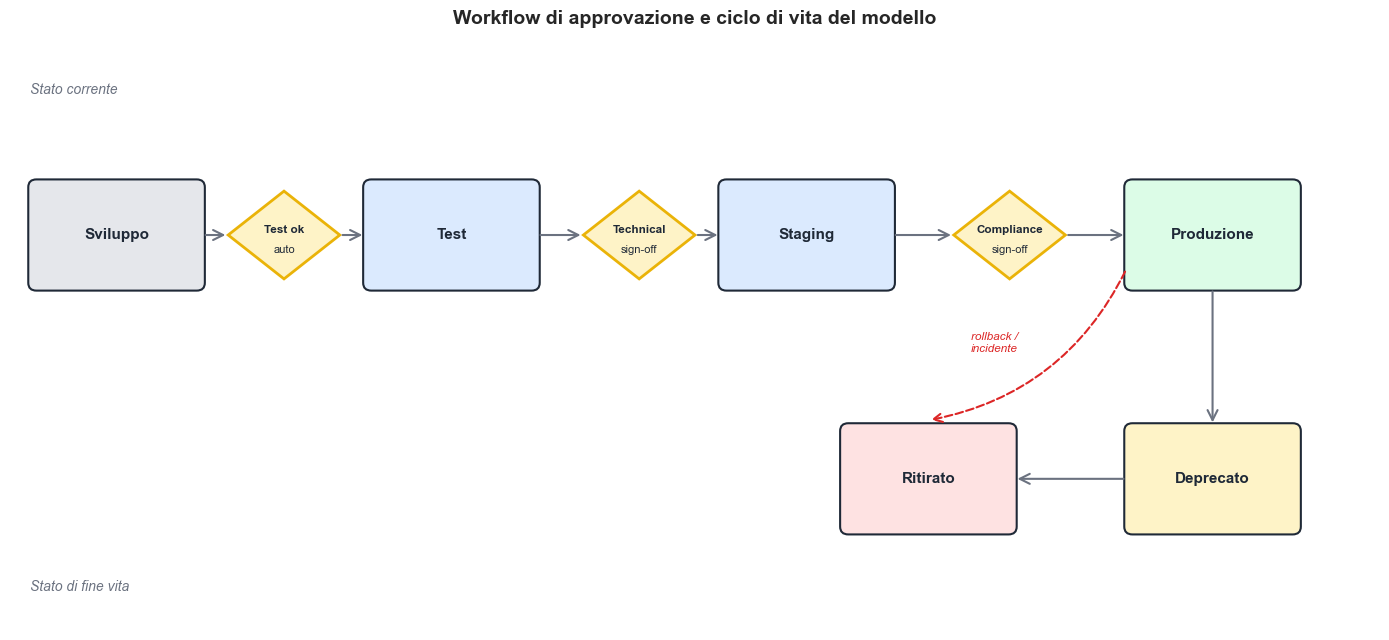

In [4]:
fig, ax = plt.subplots(figsize=(14, 6.5))

def draw_state(x, y, w, h, label, color):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.08',
                         facecolor=color, edgecolor=PALETTE['dark'], linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, fontsize=11, fontweight='bold',
            ha='center', va='center', color=PALETTE['dark'])

def draw_gate(x, y, label_top, label_bottom=None):
    diamond = plt.Polygon([(x, y + 0.45), (x + 0.55, y), (x, y - 0.45), (x - 0.55, y)],
                          facecolor=PALETTE['pale_amber'], edgecolor=PALETTE['warning'],
                          linewidth=2)
    ax.add_patch(diamond)
    ax.text(x, y + 0.05, label_top, fontsize=8.5, ha='center', va='center',
            color=PALETTE['dark'], fontweight='bold')
    if label_bottom:
        ax.text(x, y - 0.15, label_bottom, fontsize=8, ha='center', va='center',
                color=PALETTE['dark'])

def draw_arrow(x1, y1, x2, y2):
    a = FancyArrowPatch((x1, y1), (x2, y2),
                        arrowstyle='->', mutation_scale=18,
                        color=PALETTE['neutral'], linewidth=1.5)
    ax.add_patch(a)

draw_state(0.2, 3.5, 1.7, 1.1, 'Sviluppo', PALETTE['pale_gray'])
draw_state(3.5, 3.5, 1.7, 1.1, 'Test', PALETTE['pale_blue'])
draw_state(7.0, 3.5, 1.7, 1.1, 'Staging', PALETTE['pale_blue'])
draw_state(11.0,3.5, 1.7, 1.1, 'Produzione', PALETTE['pale_green'])
draw_state(11.0,1.0, 1.7, 1.1, 'Deprecato', PALETTE['pale_amber'])
draw_state(8.2, 1.0, 1.7, 1.1, 'Ritirato', PALETTE['pale_red'])

draw_gate(2.7, 4.05, 'Test ok', 'auto')
draw_gate(6.2, 4.05, 'Technical', 'sign-off')
draw_gate(9.85,4.05, 'Compliance', 'sign-off')

draw_arrow(1.9, 4.05, 2.15, 4.05)
draw_arrow(3.25, 4.05, 3.5, 4.05)
draw_arrow(5.2, 4.05, 5.65, 4.05)
draw_arrow(6.75, 4.05, 7.0, 4.05)
draw_arrow(8.7, 4.05, 9.30, 4.05)
draw_arrow(10.4, 4.05, 11.0, 4.05)
draw_arrow(11.85, 3.5, 11.85, 2.1)
draw_arrow(11.0, 1.55, 9.9, 1.55)

a = FancyArrowPatch((11.0, 3.7), (9.05, 2.15),
                    arrowstyle='->', mutation_scale=16,
                    color=PALETTE['danger'], linewidth=1.5,
                    linestyle='--',
                    connectionstyle='arc3,rad=-0.25')
ax.add_patch(a)
ax.text(9.7, 2.85, 'rollback /\nincidente', fontsize=8.5,
        color=PALETTE['danger'], style='italic', ha='center')

ax.text(0.2, 5.5, 'Stato corrente', fontsize=10, color=PALETTE['neutral'],
        style='italic')
ax.text(0.2, 0.4, 'Stato di fine vita', fontsize=10, color=PALETTE['neutral'],
        style='italic')

ax.set_xlim(0, 13.5)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Workflow di approvazione e ciclo di vita del modello',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('03_approval_workflow.png', dpi=DPI, bbox_inches='tight')
plt.show()


## Figura 4 - Albero dei KPI

Gerarchia in quattro categorie con i KPI principali per ciascuna.

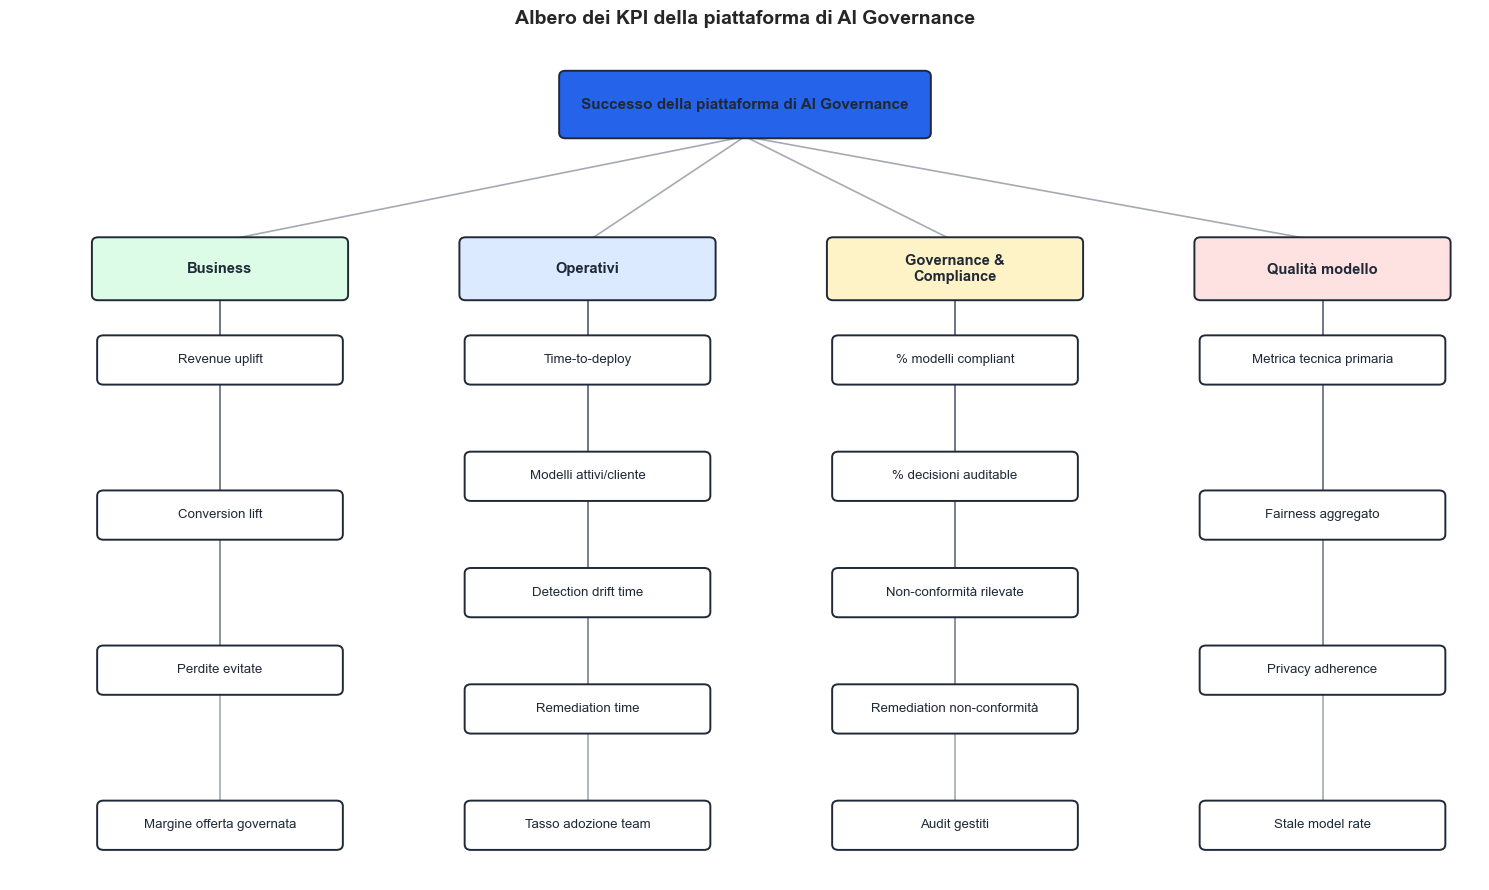

In [5]:
fig, ax = plt.subplots(figsize=(15, 9))

def draw_kpi_node(x, y, w, h, label, color, fontsize=10, fontweight='bold'):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.02,rounding_size=0.06',
                         facecolor=color, edgecolor=PALETTE['dark'], linewidth=1.4)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
            fontweight=fontweight, color=PALETTE['dark'])

def line(x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], color=PALETTE['neutral'], linewidth=1.2, alpha=0.6, zorder=0)

draw_kpi_node(7.5, 8.5, 3.5, 0.7,
              'Successo della piattaforma di AI Governance',
              PALETTE['primary'], fontsize=11)
ax.text(7.5, 8.15, '', fontsize=8)
for cx in [2.5, 6.0, 9.5, 13.0]:
    line(7.5, 8.15, cx, 7.0)

categories = [
    (2.5, 'Business',             PALETTE['pale_green']),
    (6.0, 'Operativi',            PALETTE['pale_blue']),
    (9.5, 'Governance &\nCompliance', PALETTE['pale_amber']),
    (13.0,'Qualità modello',      PALETTE['pale_red']),
]
for cx, label, color in categories:
    draw_kpi_node(cx, 6.7, 2.4, 0.65, label, color, fontsize=10.5)

kpis = {
    2.5: ['Revenue uplift', 'Conversion lift', 'Perdite evitate', 'Margine offerta governata'],
    6.0: ['Time-to-deploy', 'Modelli attivi/cliente', 'Detection drift time', 'Remediation time', 'Tasso adozione team'],
    9.5: ['% modelli compliant', '% decisioni auditable', 'Non-conformità rilevate', 'Remediation non-conformità', 'Audit gestiti'],
    13.0:['Metrica tecnica primaria', 'Fairness aggregato', 'Privacy adherence', 'Stale model rate'],
}

for cx, labels in kpis.items():
    n = len(labels)
    y_top = 5.7
    y_bottom = 0.6
    if n > 1:
        ys = np.linspace(y_top, y_bottom, n)
    else:
        ys = [y_top]
    for label, y in zip(labels, ys):
        line(cx, 6.4, cx, y + 0.18)
        draw_kpi_node(cx, y, 2.3, 0.5, label, '#ffffff', fontsize=9.5, fontweight='normal')

ax.set_xlim(0.5, 14.5)
ax.set_ylim(0, 9.2)
ax.axis('off')
ax.set_title('Albero dei KPI della piattaforma di AI Governance',
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('04_kpi_tree.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Figura 5 - Roadmap gantt

PoC a settimane (1-8), MVP a mesi (3-8), Scale a mesi (9-18). Milestone diamanti.

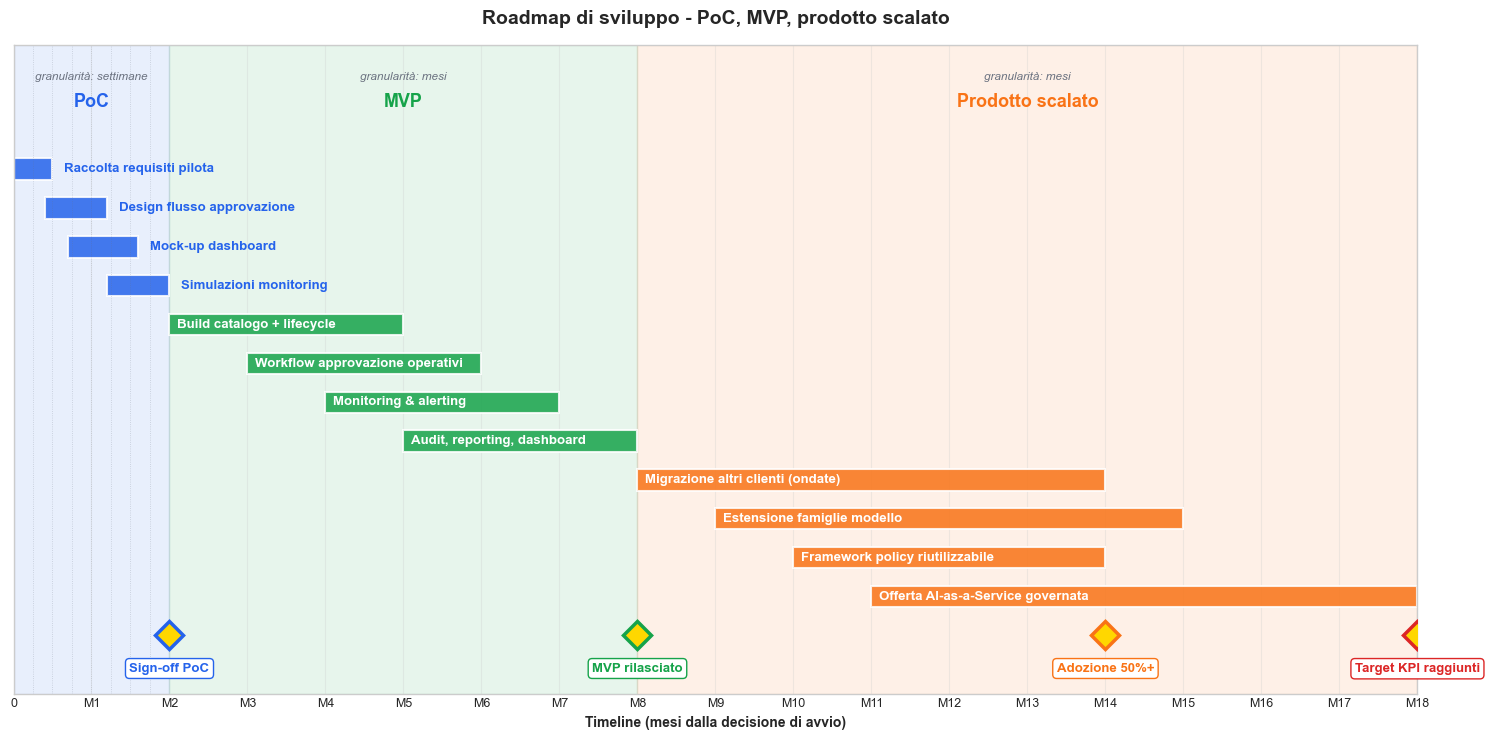

In [6]:
fig, ax = plt.subplots(figsize=(15, 7.5))

MONTHS_TOTAL = 18
LABEL_MIN_WIDTH = 1.5

ax.axvspan(0, 2, alpha=0.10, color=PALETTE['primary'], zorder=0)
ax.axvspan(2, 8, alpha=0.10, color=PALETTE['secondary'], zorder=0)
ax.axvspan(8, 18, alpha=0.10, color=PALETTE['accent'], zorder=0)

tasks = [
    {'name': 'Raccolta requisiti pilota',          'start': 0.0,  'end': 0.5,  'phase': 'poc'},
    {'name': 'Design flusso approvazione',         'start': 0.4,  'end': 1.2,  'phase': 'poc'},
    {'name': 'Mock-up dashboard',                  'start': 0.7,  'end': 1.6,  'phase': 'poc'},
    {'name': 'Simulazioni monitoring',             'start': 1.2,  'end': 2.0,  'phase': 'poc'},
    {'name': 'Build catalogo + lifecycle',         'start': 2.0,  'end': 5.0,  'phase': 'mvp'},
    {'name': 'Workflow approvazione operativi',    'start': 3.0,  'end': 6.0,  'phase': 'mvp'},
    {'name': 'Monitoring & alerting',              'start': 4.0,  'end': 7.0,  'phase': 'mvp'},
    {'name': 'Audit, reporting, dashboard',        'start': 5.0,  'end': 8.0,  'phase': 'mvp'},
    {'name': 'Migrazione altri clienti (ondate)',  'start': 8.0,  'end': 14.0, 'phase': 'scale'},
    {'name': 'Estensione famiglie modello',        'start': 9.0,  'end': 15.0, 'phase': 'scale'},
    {'name': 'Framework policy riutilizzabile',    'start': 10.0, 'end': 14.0, 'phase': 'scale'},
    {'name': 'Offerta AI-as-a-Service governata',  'start': 11.0, 'end': 18.0, 'phase': 'scale'},
]

color_for = {'poc': PALETTE['primary'], 'mvp': PALETTE['secondary'], 'scale': PALETTE['accent']}

for i, t in enumerate(tasks):
    y = len(tasks) - i - 1
    duration = t['end'] - t['start']
    color = color_for[t['phase']]
    ax.barh(y, duration, left=t['start'], height=0.55,
            color=color, alpha=0.85,
            edgecolor='white', linewidth=1.5)
    if duration >= LABEL_MIN_WIDTH:
        ax.text(t['start'] + 0.1, y, t['name'],
                va='center', ha='left', fontsize=9.5,
                color='white', fontweight='bold')
    else:
        ax.text(t['end'] + 0.15, y, t['name'],
                va='center', ha='left', fontsize=9.5,
                color=color, fontweight='bold')

ax.text(1.0, len(tasks) + 0.6, 'PoC',
        ha='center', fontsize=13, fontweight='bold', color=PALETTE['primary'])
ax.text(5.0, len(tasks) + 0.6, 'MVP',
        ha='center', fontsize=13, fontweight='bold', color=PALETTE['secondary'])
ax.text(13.0, len(tasks) + 0.6, 'Prodotto scalato',
        ha='center', fontsize=13, fontweight='bold', color=PALETTE['accent'])

ax.text(1.0, len(tasks) + 1.3, 'granularità: settimane',
        ha='center', fontsize=8.5, color=PALETTE['neutral'], style='italic')
ax.text(5.0, len(tasks) + 1.3, 'granularità: mesi',
        ha='center', fontsize=8.5, color=PALETTE['neutral'], style='italic')
ax.text(13.0, len(tasks) + 1.3, 'granularità: mesi',
        ha='center', fontsize=8.5, color=PALETTE['neutral'], style='italic')

milestones = [
    (2,  'Sign-off PoC',         PALETTE['primary']),
    (8,  'MVP rilasciato',       PALETTE['secondary']),
    (14, 'Adozione 50%+',        PALETTE['accent']),
    (18, 'Target KPI raggiunti', PALETTE['danger']),
]
for m_x, m_label, m_color in milestones:
    ax.plot(m_x, -1.0, marker='D', markersize=14,
            color='gold', markeredgecolor=m_color, markeredgewidth=2.5, zorder=5)
    ax.text(m_x, -1.7, m_label, ha='center', va='top', fontsize=9.5,
            color=m_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=m_color, linewidth=1))

ax.set_yticks([])
ax.set_xlim(0, MONTHS_TOTAL)
ax.set_ylim(-2.5, len(tasks) + 2.2)

ax.set_xticks(range(0, MONTHS_TOTAL + 1, 1))
ax.set_xticklabels([f'M{i}' if i > 0 else '0' for i in range(0, MONTHS_TOTAL + 1)],
                   fontsize=9)
for w in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75]:
    ax.axvline(w, color=PALETTE['neutral'], linestyle=':', alpha=0.3, linewidth=0.6)

ax.set_xlabel('Timeline (mesi dalla decisione di avvio)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_title('Roadmap di sviluppo - PoC, MVP, prodotto scalato',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('05_roadmap_gantt.png', dpi=DPI, bbox_inches='tight')
plt.show()


## Figura 6 - Risk heatmap

Probabilità × impatto, ogni rischio posizionato e codificato per ID.

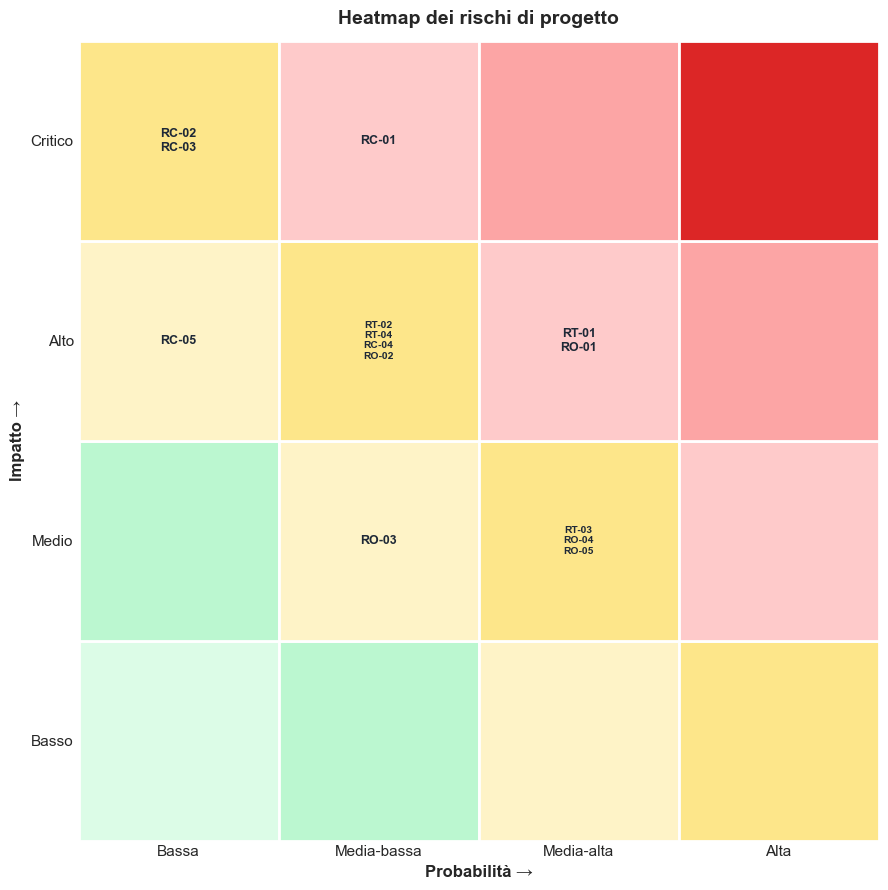

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))

grid_colors = [
    ['#dcfce7', '#bbf7d0', '#fef3c7', '#fde68a'],
    ['#bbf7d0', '#fef3c7', '#fde68a', '#fecaca'],
    ['#fef3c7', '#fde68a', '#fecaca', '#fca5a5'],
    ['#fde68a', '#fecaca', '#fca5a5', '#dc2626'],
]

for i in range(4):
    for j in range(4):
        ax.add_patch(Rectangle((j, i), 1, 1,
                               facecolor=grid_colors[i][j],
                               edgecolor='white', linewidth=2))

risks = [
    {'id': 'RT-01', 'p': 3, 'i': 3, 'label': 'Frammentaz.\nambienti cliente'},
    {'id': 'RT-02', 'p': 2, 'i': 3, 'label': 'Performance\nsotto carico'},
    {'id': 'RT-03', 'p': 3, 'i': 2, 'label': 'Falsi positivi\nmonitoring'},
    {'id': 'RT-04', 'p': 2, 'i': 3, 'label': 'Falsi negativi\ndrift'},
    {'id': 'RC-01', 'p': 2, 'i': 4, 'label': 'Decisione\ndiscriminatoria'},
    {'id': 'RC-02', 'p': 1, 'i': 4, 'label': 'Violazione\nGDPR'},
    {'id': 'RC-03', 'p': 1, 'i': 4, 'label': 'Esposiz.\nlegale grave'},
    {'id': 'RC-04', 'p': 2, 'i': 3, 'label': 'Cambio\nnormativo'},
    {'id': 'RC-05', 'p': 1, 'i': 3, 'label': 'Audit\ntrova lacune'},
    {'id': 'RO-01', 'p': 3, 'i': 3, 'label': 'Resistenza\nteam'},
    {'id': 'RO-02', 'p': 2, 'i': 3, 'label': 'Frammentaz.\ndecisionale'},
    {'id': 'RO-03', 'p': 2, 'i': 2, 'label': 'Key person\nrisk'},
    {'id': 'RO-04', 'p': 3, 'i': 2, 'label': 'Sotto-invest.\nchange'},
    {'id': 'RO-05', 'p': 3, 'i': 2, 'label': 'Tempi\napprovazione'},
]

from collections import defaultdict
cell_risks = defaultdict(list)
for r in risks:
    cell_risks[(r['p'], r['i'])].append(r['id'])

for (p, i), ids in cell_risks.items():
    x_center = p - 0.5
    y_center = i - 0.5
    text = '\n'.join(ids)
    fontsize = 9 if len(ids) <= 2 else 7.5
    ax.text(x_center, y_center, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=PALETTE['dark'])

p_labels = ['Bassa', 'Media-bassa', 'Media-alta', 'Alta']
i_labels = ['Basso', 'Medio', 'Alto', 'Critico']
ax.set_xticks(np.arange(0.5, 4.5))
ax.set_yticks(np.arange(0.5, 4.5))
ax.set_xticklabels(p_labels, fontsize=11)
ax.set_yticklabels(i_labels, fontsize=11)
ax.set_xlabel('Probabilità →', fontsize=12, fontweight='bold')
ax.set_ylabel('Impatto →', fontsize=12, fontweight='bold')

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Heatmap dei rischi di progetto', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('06_risk_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Figura 7 - Mappa stakeholder

Influenza × interesse, codifica colore interno/esterno.

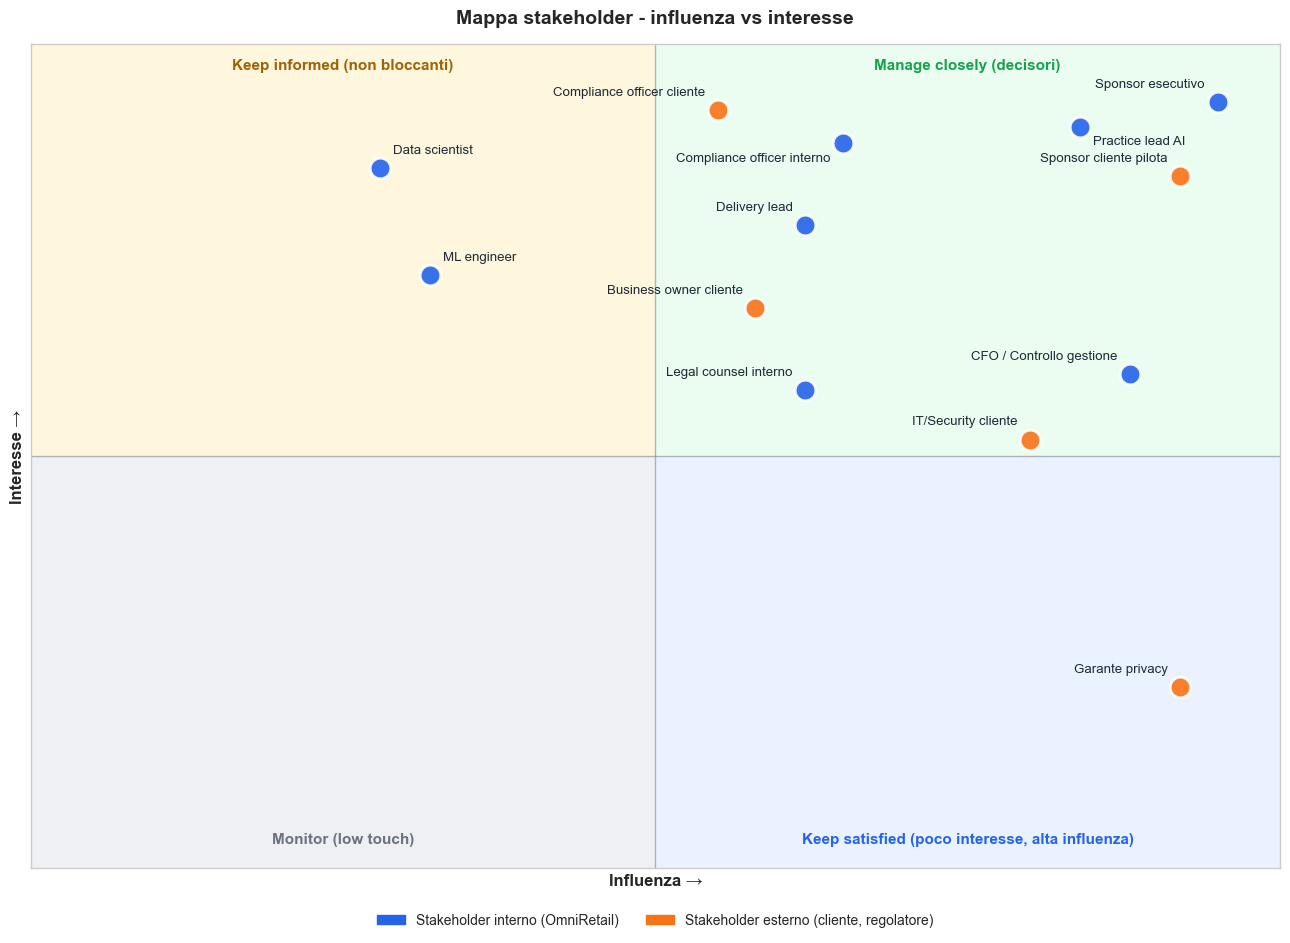

In [8]:
fig, ax = plt.subplots(figsize=(13, 9.5))

ax.add_patch(Rectangle((0.5, 0.5), 0.5, 0.5,
                       facecolor=PALETTE['pale_green'], alpha=0.6, zorder=0))
ax.add_patch(Rectangle((0.0, 0.5), 0.5, 0.5,
                       facecolor=PALETTE['pale_amber'], alpha=0.6, zorder=0))
ax.add_patch(Rectangle((0.5, 0.0), 0.5, 0.5,
                       facecolor=PALETTE['pale_blue'], alpha=0.6, zorder=0))
ax.add_patch(Rectangle((0.0, 0.0), 0.5, 0.5,
                       facecolor=PALETTE['pale_gray'], alpha=0.6, zorder=0))

ax.text(0.75, 0.97, 'Manage closely (decisori)', ha='center',
        fontsize=11, fontweight='bold', color=PALETTE['secondary'])
ax.text(0.25, 0.97, 'Keep informed (non bloccanti)', ha='center',
        fontsize=11, fontweight='bold', color='#a16207')
ax.text(0.75, 0.03, 'Keep satisfied (poco interesse, alta influenza)', ha='center',
        fontsize=11, fontweight='bold', color=PALETTE['primary'])
ax.text(0.25, 0.03, 'Monitor (low touch)', ha='center',
        fontsize=11, fontweight='bold', color=PALETTE['neutral'])

stakeholders = [
    {'name': 'Sponsor esecutivo',          'inf': 0.95, 'int': 0.93, 'type': 'i', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'Practice lead AI',           'inf': 0.84, 'int': 0.90, 'type': 'i', 'dx':  0.01, 'dy': -0.022, 'ha': 'left'},
    {'name': 'Sponsor cliente pilota',     'inf': 0.92, 'int': 0.84, 'type': 'e', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'CFO / Controllo gestione',   'inf': 0.88, 'int': 0.60, 'type': 'i', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'IT/Security cliente',        'inf': 0.80, 'int': 0.52, 'type': 'e', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'Garante privacy',            'inf': 0.92, 'int': 0.22, 'type': 'e', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'Compliance officer interno', 'inf': 0.65, 'int': 0.88, 'type': 'i', 'dx': -0.01, 'dy': -0.022, 'ha': 'right'},
    {'name': 'Legal counsel interno',      'inf': 0.62, 'int': 0.58, 'type': 'i', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'Delivery lead',              'inf': 0.62, 'int': 0.78, 'type': 'i', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'Data scientist',             'inf': 0.28, 'int': 0.85, 'type': 'i', 'dx':  0.01, 'dy':  0.018, 'ha': 'left'},
    {'name': 'ML engineer',                'inf': 0.32, 'int': 0.72, 'type': 'i', 'dx':  0.01, 'dy':  0.018, 'ha': 'left'},
    {'name': 'Compliance officer cliente', 'inf': 0.55, 'int': 0.92, 'type': 'e', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
    {'name': 'Business owner cliente',     'inf': 0.58, 'int': 0.68, 'type': 'e', 'dx': -0.01, 'dy':  0.018, 'ha': 'right'},
]

for s in stakeholders:
    color = PALETTE['primary'] if s['type'] == 'i' else PALETTE['accent']
    ax.scatter(s['inf'], s['int'], s=220, color=color,
               edgecolor='white', linewidth=2, zorder=3, alpha=0.9)
    ax.annotate(s['name'], xy=(s['inf'], s['int']),
                xytext=(s['inf'] + s['dx'], s['int'] + s['dy']),
                fontsize=9.5, ha=s['ha'], color=PALETTE['dark'])

ax.axhline(0.5, color=PALETTE['neutral'], linewidth=1, alpha=0.5)
ax.axvline(0.5, color=PALETTE['neutral'], linewidth=1, alpha=0.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Influenza →', fontsize=12, fontweight='bold')
ax.set_ylabel('Interesse →', fontsize=12, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])

internal_patch = mpatches.Patch(color=PALETTE['primary'], label='Stakeholder interno (OmniRetail)')
external_patch = mpatches.Patch(color=PALETTE['accent'], label='Stakeholder esterno (cliente, regolatore)')
ax.legend(handles=[internal_patch, external_patch],
          loc='upper center', bbox_to_anchor=(0.5, -0.04), ncol=2,
          fontsize=10, framealpha=0.95, edgecolor=PALETTE['neutral'])

ax.set_title('Mappa stakeholder - influenza vs interesse',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('07_stakeholder_map.png', dpi=DPI, bbox_inches='tight')
plt.show()